In [38]:
import matplotlib.pylab as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web
from tidy3d import Scene, material_library
from tidy3d.plugins.mode import ModeSolver

Wavelengths Used

In [39]:
lda0 = 0.75  # 750 nm; spatial units are µm in Tidy3D
freq0 = td.C_0 / lda0
fwidth = freq0 / 10  # spectral bandwidth for Gaussian pulse


Import Materials Data

In [40]:
si_medium = material_library["cSi"].medium
sio2_medium = material_library["SiO2"].medium
sin_medium = material_library["SiN"].medium

20:34:25 PDT WARNING: Since Tidy3D 2.7, the default variant for silicon dioxide 
             has been switched from 'Horiba' to 'Palik_Lossless'.               

Create Structures

In [41]:
substrate = td.Structure(
    geometry=td.Box(center=(0, 0, -1), size=(4, 10, 2)), medium=si_medium
)
glass = td.Structure(
    geometry=td.Box(center=(0, 0, 5), size=(4, 10, 10)), medium=sio2_medium
)
# Must come after `glass` so nitride overrides SiO2 where they overlap.
nitride_ridge = td.Structure(
    geometry=td.Box(center=(0, 0, 5), size=(0.5, 10, 0.22)), medium=sin_medium
)

In [42]:
# Fundamental TE-like mode of the SiN ridge; propagates along +y through the core.
mode_spec = td.ModeSpec(num_modes=6, target_neff=2.0, filter_pol="te")
mode_source = td.ModeSource(
    center=(0, -4.0, 5),
    size=(2.5, 0, 2.5),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    mode_spec=mode_spec,
    mode_index=0,
    direction="+",
    name="sin_mode",
)

             WARNING: 'filter_pol' is deprecated and will be removed in future  
             versions. Please use 'sort_spec' instead.                          

In [43]:
sim = td.Simulation(
    center=(0, 0, 4.0),
    size=(10, 15, 13.0),
    grid_spec=td.GridSpec.auto(
        wavelength=lda0,
        min_steps_per_wvl=25,
    ),
    structures=[substrate, glass, nitride_ridge],
    sources=[mode_source],
    run_time=3e-13,
)

             WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'. Alternatively, you can install 
             the package 'tidy3d-extras' using 'pip install "tidy3d"' and set   
             'config.simulation.use_local_subpixel=True'.                       

20:34:38 PDT WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 4 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 5 does not    
             decay at the plane boundaries.                                     

20:34:50 PDT WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 4 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 5 does not    
             decay at the plane boundaries.                                     


--- y = -4 µm (source plane) ---
  mode_index 0:  n_eff = 1.61526
  mode_index 1:  n_eff = 1.56948
  mode_index 2:  n_eff = 1.44674
  mode_index 3:  n_eff = 1.44023
  mode_index 4:  n_eff = 1.43954
  mode_index 5:  n_eff = 1.43849

--- y = 0 (mid waveguide) ---
  mode_index 0:  n_eff = 1.61526
  mode_index 1:  n_eff = 1.56948
  mode_index 2:  n_eff = 1.44674
  mode_index 3:  n_eff = 1.44023
  mode_index 4:  n_eff = 1.43954
  mode_index 5:  n_eff = 1.43849


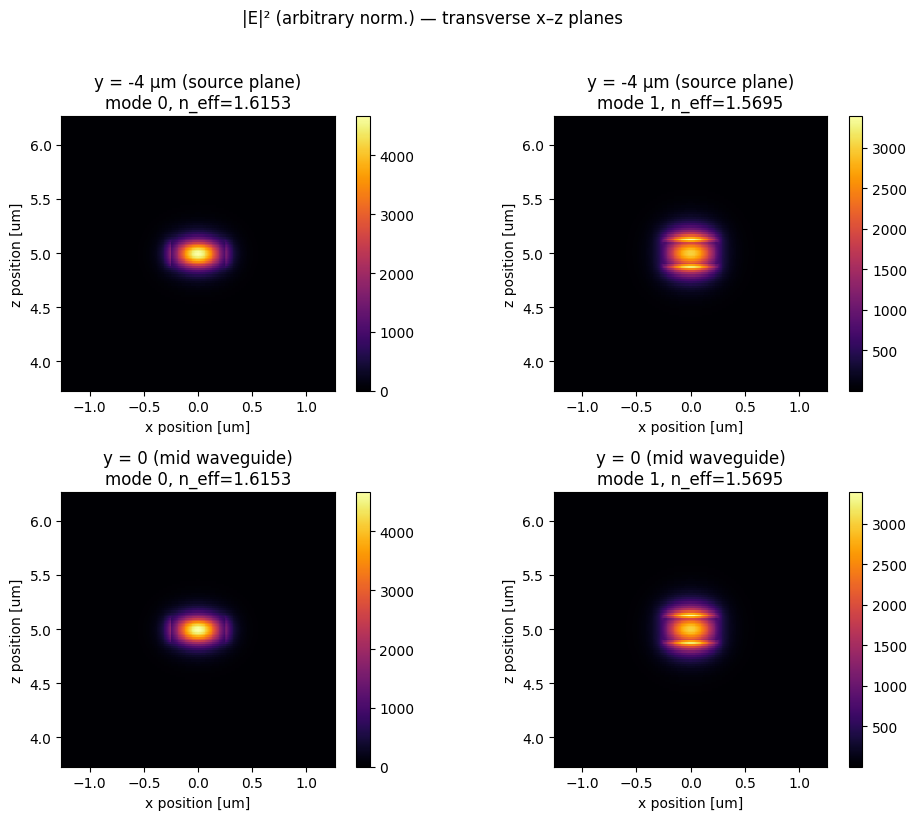

In [44]:
# Eigenmode solve at 750 nm: n_eff table + |E|² on transverse (x–z) planes.
mode_spec_ms = td.ModeSpec(num_modes=6, target_neff=2.0)
cross_sections = {
    "y = -4 µm (source plane)": td.Box(center=(0, -4.0, 5), size=(2.5, 0, 2.5)),
    "y = 0 (mid waveguide)": td.Box(center=(0, 0, 5), size=(2.5, 0, 2.5)),
}

mode_results = {}
for label, plane in cross_sections.items():
    solver = ModeSolver(
        simulation=sim,
        plane=plane,
        mode_spec=mode_spec_ms,
        freqs=[freq0],
        direction="+",
    )
    mode_results[label] = (solver, solver.solve())

for label, (solver, mdata) in mode_results.items():
    print(f"\n--- {label} ---")
    n_eff = mdata.n_eff.sel(f=freq0, method="nearest")
    for m in n_eff.coords["mode_index"].values:
        ne = float(n_eff.sel(mode_index=int(m)).values)
        print(f"  mode_index {int(m)}:  n_eff = {ne:.5f}")

fig, axes = plt.subplots(2, 2, figsize=(10, 8), tight_layout=True)
for row, (label, (solver, mdata)) in enumerate(mode_results.items()):
    n0 = float(mdata.n_eff.sel(f=freq0, mode_index=0, method="nearest").values)
    for col, midx in enumerate([0, 1]):
        ax = axes[row, col]
        Ex = mdata.Ex.sel(f=freq0, mode_index=midx, method="nearest")
        Ey = mdata.Ey.sel(f=freq0, mode_index=midx, method="nearest")
        Ez = mdata.Ez.sel(f=freq0, mode_index=midx, method="nearest")
        E2 = np.abs(Ex) ** 2 + np.abs(Ey) ** 2 + np.abs(Ez) ** 2
        E2.plot(ax=ax, x="x", y="z", cmap="inferno")
        nm = float(mdata.n_eff.sel(f=freq0, mode_index=midx, method="nearest").values)
        ax.set_title(f"{label}\nmode {midx}, n_eff={nm:.4f}")
        ax.set_aspect("equal")
plt.suptitle("|E|² (arbitrary norm.) — transverse x–z planes", y=1.02)
plt.show()

In [45]:
sim.plot_3d()